<a href="https://colab.research.google.com/github/gopika-vit/-AI-DS-/blob/main/ROP2_Hairfall_Prediction_Explainable_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),  # 🔥 FIX HERE
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

In [ ]:
dataset_path = "/content/drive/MyDrive/data0330"

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['bald', 'notbald']
Total images: 1113


In [ ]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
model = models.resnet50(pretrained=True)

# Remove last layer (classification layer)
model = nn.Sequential(*list(model.children())[:-1])

model = model.to(device)
model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [ ]:
features_list = []
labels_list = []

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)

        outputs = model(images)
        outputs = outputs.view(outputs.size(0), -1)

        features_list.append(outputs.cpu())
        labels_list.append(labels)

In [ ]:
features_tensor = torch.cat(features_list)
labels_tensor = torch.cat(labels_list)

print("Feature shape:", features_tensor.shape)
print("Labels shape:", labels_tensor.shape)

Feature shape: torch.Size([1113, 2048])
Labels shape: torch.Size([1113])


In [ ]:
np.save("image_features.npy", features_tensor.numpy())
np.save("labels.npy", labels_tensor.numpy())

print("Features saved successfully!")

Features saved successfully!


In [ ]:
import numpy as np

features = np.load("/content/image_features.npy")
print(features.shape)

(1113, 2048)


In [ ]:
np.save("/content/drive/MyDrive/image_features.npy", features_tensor.numpy())
np.save("/content/drive/MyDrive/labels.npy", labels_tensor.numpy())

In [ ]:
import numpy as np
import pandas as pd

# Load image features
image_features = np.load("/content/image_features.npy")

# Load labels
labels = np.load("/content/labels.npy")

# Load CSV dataset
df = pd.read_csv("/content/drive/MyDrive/Predict Hair Fall.csv")

print("Image features:", image_features.shape)
print("Labels:", labels.shape)
print("CSV shape:", df.shape)

Image features: (1113, 2048)
Labels: (1113,)
CSV shape: (999, 13)


In [ ]:
print(df.columns)
print(df.head())

Index(['Id', 'Genetics', 'Hormonal Changes', 'Medical Conditions',
       'Medications & Treatments', 'Nutritional Deficiencies ', 'Stress',
       'Age', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking',
       'Weight Loss ', 'Hair Loss'],
      dtype='object')
       Id Genetics Hormonal Changes Medical Conditions  \
0  133992      Yes               No            No Data   
1  148393       No               No             Eczema   
2  155074       No               No         Dermatosis   
3  118261      Yes              Yes           Ringworm   
4  111915       No               No          Psoriasis   

  Medications & Treatments Nutritional Deficiencies     Stress  Age  \
0                  No Data      Magnesium deficiency  Moderate   19   
1              Antibiotics      Magnesium deficiency      High   43   
2         Antifungal Cream        Protein deficiency  Moderate   26   
3              Antibiotics        Biotin Deficiency   Moderate   46   
4                 Ac

In [ ]:
df = df.drop(columns=["Id"])

KeyError: "['Id'] not found in axis"

In [ ]:
labels_csv = df["Hair Loss"]
df = df.drop(columns=["Hair Loss"])

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df_encoded = pd.get_dummies(df)

print("Encoded shape:", df_encoded.shape)

Encoded shape: (999, 49)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
tabular_data = scaler.fit_transform(df_encoded)

In [ ]:
min_samples = min(len(image_features), len(tabular_data))

image_features = image_features[:min_samples]
tabular_data = tabular_data[:min_samples]
labels = labels[:min_samples]   # from image dataset

In [ ]:
combined_features = np.concatenate((image_features, tabular_data), axis=1)

print("Final feature shape:", combined_features.shape)

Final feature shape: (999, 2097)


In [ ]:
np.save("/content/combined_features.npy", combined_features)
np.save("/content/final_labels.npy", labels)

In [ ]:
import numpy as np

X = np.load("/content/combined_features.npy")
y = np.load("/content/final_labels.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (999, 2097)
y shape: (999,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np

# Load data
X = np.load("/content/combined_features.npy")
y = np.load("/content/final_labels.npy")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build model
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X.shape[1],)),
    layers.Dropout(0.4),   # ✅ balanced dropout

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),   # ✅ balanced dropout

    layers.Dense(128, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping (less aggressive)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.6182 - loss: 0.7278 - val_accuracy: 0.6750 - val_loss: 0.5407
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6854 - loss: 0.6067 - val_accuracy: 0.8188 - val_loss: 0.4269
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7387 - loss: 0.5458 - val_accuracy: 0.7625 - val_loss: 0.4479
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7637 - loss: 0.4829 - val_accuracy: 0.8438 - val_loss: 0.3408
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7950 - loss: 0.4139 - val_accuracy: 0.7750 - val_loss: 0.4260
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8106 - loss: 0.3994 - val_accuracy: 0.8250 - val_loss: 0.3263
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8247 - loss: 0.3879 - val_accuracy: 0.8250 - val_loss: 0.3333
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8310 - loss: 0.3429 - val_accuracy: 0.8438 - val_los

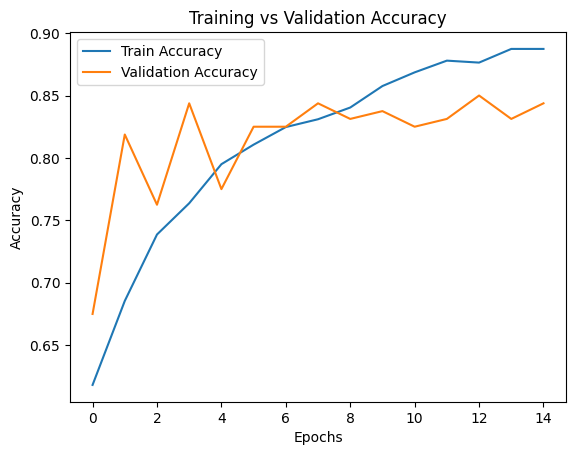

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8607 - loss: 0.3316 - val_accuracy: 0.8313 - val_loss: 0.3157
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8560 - loss: 0.3295 - val_accuracy: 0.8250 - val_loss: 0.3868
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8545 - loss: 0.3171 - val_accuracy: 0.8188 - val_loss: 0.3429
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8545 - loss: 0.3188 - val_accuracy: 0.8313 - val_loss: 0.2982
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8560 - loss: 0.3130 - val_accuracy: 0.8500 - val_loss: 0.3094
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8592 - loss: 0.3064 - val_accuracy: 0.8687 - val_loss: 0.3259
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8920 - loss: 0.2711 - val_accuracy: 0.8313 - val_loss: 0.3179
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8795 - loss: 0.2659 - val_accuracy: 0.8313 - val_loss

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8050 - loss: 0.4842
Test Accuracy: 0.8050000071525574


In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[78 15]
 [21 86]]
              precision    recall  f1-score   support

           0       0.79      0.84      0.81        93
           1       0.85      0.80      0.83       107

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200



In [ ]:
import numpy as np

# Load your combined features
X = np.load("/content/combined_features.npy")
y = np.load("/content/final_labels.npy")

sequence_length = 5  # time steps

X_seq = []
y_seq = []

for i in range(len(X) - sequence_length):
    X_seq.append(X[i:i+sequence_length])
    y_seq.append(y[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)

Sequence shape: (994, 5, 2097)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(128, input_shape=(X_seq.shape[1], X_seq.shape[2])),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │     1,139,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,033 (4.38 MB)

 Trainable params: 1,148,033 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

X = np.load("/content/combined_features.npy")
y = np.load("/content/final_labels.npy")

def simulate_time_series(sample, steps=5):
    sequence = []

    for t in range(steps):
        modified = sample.copy()

        # simulate worsening condition
        noise = np.random.normal(0, 0.02, size=sample.shape)
        modified += noise

        sequence.append(modified)

    return np.array(sequence)

# Build sequences
X_seq = []
y_seq = []

for i in range(len(X)):
    seq = simulate_time_series(X[i])
    X_seq.append(seq)
    y_seq.append(y[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("New sequence shape:", X_seq.shape)

New sequence shape: (999, 5, 2097)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

history = model_lstm.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6698 - loss: 0.5919 - val_accuracy: 0.7750 - val_loss: 0.4819
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7887 - loss: 0.4564 - val_accuracy: 0.7937 - val_loss: 0.4150
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8200 - loss: 0.4058 - val_accuracy: 0.8500 - val_loss: 0.3607
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8466 - loss: 0.3191 - val_accuracy: 0.8313 - val_loss: 0.3492
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8685 - loss: 0.3230 - val_accuracy: 0.8375 - val_loss: 0.3523
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8905 - loss: 0.2607 - val_accuracy: 0.8500 - val_loss: 0.3384
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8967 - loss: 0.2278 - val_accuracy: 0.8438 - val_loss: 0.3157
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9155 - loss: 0.2057 - val_accuracy: 0.7688 - v

In [ ]:
sample = X[0]

for i in range(5):
    sample = sample + np.random.normal(0, 0.05, sample.shape)

    pred = model.predict(sample.reshape(1, -1))
    print(f"Step {i}: Hair loss probability =", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
Step 0: Hair loss probability = 0.008866992
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Step 1: Hair loss probability = 0.011145281
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Step 2: Hair loss probability = 0.014322503
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Step 3: Hair loss probability = 0.013935443
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Step 4: Hair loss probability = 0.017166696


In [ ]:
sample = X[0]

print("Digital Twin Simulation:")

for step in range(5):
    sample = sample + np.random.normal(0, 0.03, sample.shape)

    pred = model.predict(sample.reshape(1, -1))

    print(f"Step {step+1}: Probability of Hair Loss = {pred[0][0]:.4f}")

Digital Twin Simulation:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Step 1: Probability of Hair Loss = 0.0081
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Step 2: Probability of Hair Loss = 0.0079
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Step 3: Probability of Hair Loss = 0.0088
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Step 4: Probability of Hair Loss = 0.0094
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Step 5: Probability of Hair Loss = 0.0095


In [ ]:
print(type(X_test))
print(X_test.shape)

<class 'numpy.ndarray'>
(200, 5, 2097)


In [ ]:
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
model_lstm.predict(X_seq)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


array([[1.05891563e-02],
       [9.52942371e-01],
       [9.98036563e-01],
       [9.98896599e-01],
       [1.50019617e-03],
       [9.94857550e-01],
       [9.96580064e-01],
       [9.99183714e-01],
       [9.99271691e-01],
       [9.99589860e-01],
       [1.57942828e-02],
       [9.96858716e-01],
       [3.07983765e-03],
       [9.62123334e-01],
       [8.97116866e-03],
       [2.89309137e-02],
       [1.07978994e-03],
       [2.22333759e-01],
       [9.99542952e-01],
       [1.27368197e-01],
       [4.36140457e-03],
       [1.09102754e-02],
       [9.98876274e-01],
       [9.79449153e-01],
       [9.81443524e-01],
       [7.55307078e-01],
       [9.88622844e-01],
       [6.25099661e-03],
       [9.95268524e-01],
       [9.97620285e-01],
       [1.11235762e-02],
       [9.97186720e-01],
       [9.98506367e-01],
       [9.83282566e-01],
       [3.02027315e-01],
       [9.00469005e-01],
       [6.11814186e-02],
       [1.42593561e-02],
       [9.98841465e-01],
       [8.52516480e-03],


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step
Sample probabilities: [1.4489298e-01 8.9731312e-01 9.7234994e-01 9.9631077e-01 4.5039143e-02
 1.4868872e-01 1.8157707e-01 3.4411270e-02 6.7269546e-01 3.6770295e-04]


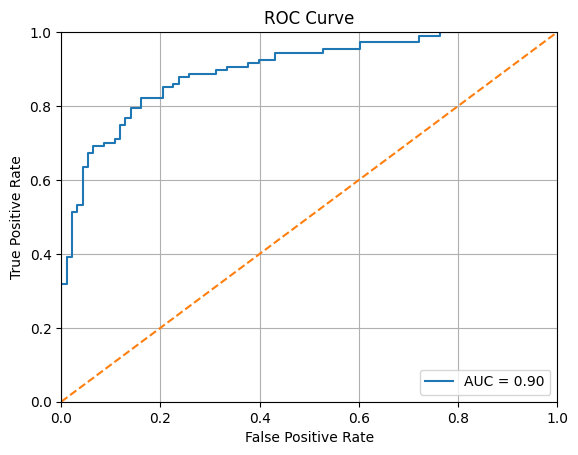

AUC Score: 0.8985026630489398


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Ensure correct format
X_test = np.array(X_test).astype('float32')

# Get probability predictions (IMPORTANT)
y_probs = model.predict(X_test).ravel()

print("Sample probabilities:", y_probs[:10])  # should NOT be just 0/1

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot properly
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
# Final training accuracy
train_acc = history.history['accuracy'][-1]

# Final validation accuracy
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

Final Training Accuracy: 0.8873239159584045
Final Validation Accuracy: 0.84375


In [ ]:
best_val_acc = max(history.history['val_accuracy'])

print("Best Validation Accuracy:", best_val_acc)

Best Validation Accuracy: 0.8500000238418579
